In [14]:
import json
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
from collections import Counter
from torchvision.datasets import ImageFolder
from torchvision import transforms
from tqdm import tqdm

os.chdir("C:/Users/HP/Desktop/Brain_Cancer_MRI")

from src.data.data_module import BrainMRIDataModule
from src.utils.file_io import load_config, load_objects
from src.utils.visualizations import class_counter, plot_raw_vs_transformed_imgs, plot_train_vs_val, plot_learning_rates

In [2]:
data_dir = "../data/Brain_Cancer"
if os.path.exists(data_dir):
    ln_items = os.listdir(data_dir)
    print(ln_items)

In [3]:
configs = load_config("configs/config.yaml")

In [4]:
data_module = BrainMRIDataModule(configs)
train_dataset, val_dataset, test_dataset = data_module.get_datasets(save_mean_std_path="artifacts/preprocessing/normalization_mean_std.json")
train_loader, val_loader, test_loader = data_module.get_dataloaders()

100%|██████████| 4542/4542 [01:15<00:00, 59.98it/s] 


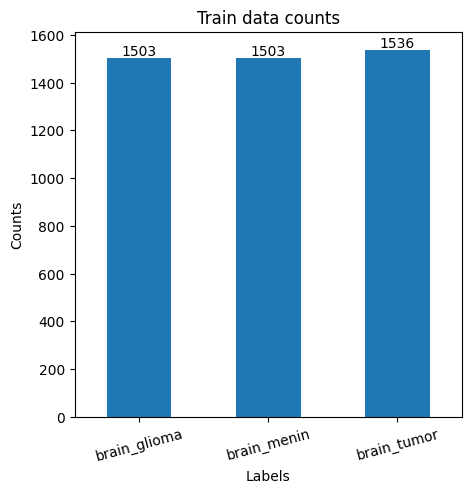

brain_glioma    1503
brain_menin     1503
brain_tumor     1536
dtype: int64

In [5]:
class_counter(train_dataset, title="Train data counts", savename="train_counts")

100%|██████████| 756/756 [00:06<00:00, 122.09it/s]


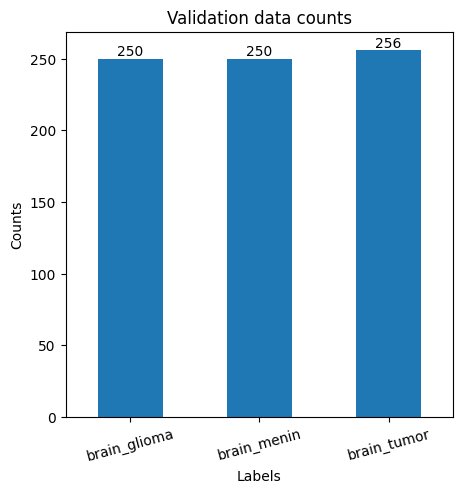

brain_glioma    250
brain_menin     250
brain_tumor     256
dtype: int64

In [6]:
class_counter(val_dataset, title="Validation data counts", savename="val_counts")

100%|██████████| 758/758 [00:06<00:00, 120.80it/s]


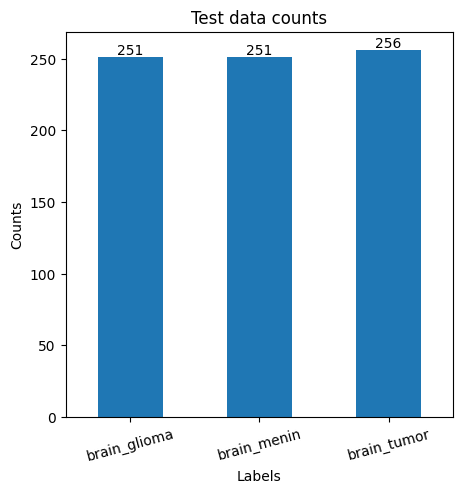

brain_glioma    251
brain_menin     251
brain_tumor     256
dtype: int64

In [7]:
class_counter(test_dataset, title="Test data counts", savename="test_counts")

From the three graphs above, we can obviously all splits and the dataset as a whole is balanced. This is very good as we need not worry about dealing with all the problems that come with imbalanced dataset. Ironically, in most medical datasets, this is contrary. Most (if not all) medical data has class imbalance.

[0.1545172482728958, 0.1545172482728958, 0.1545172482728958] [0.1720396727323532, 0.1720396727323532, 0.1720396727323532]


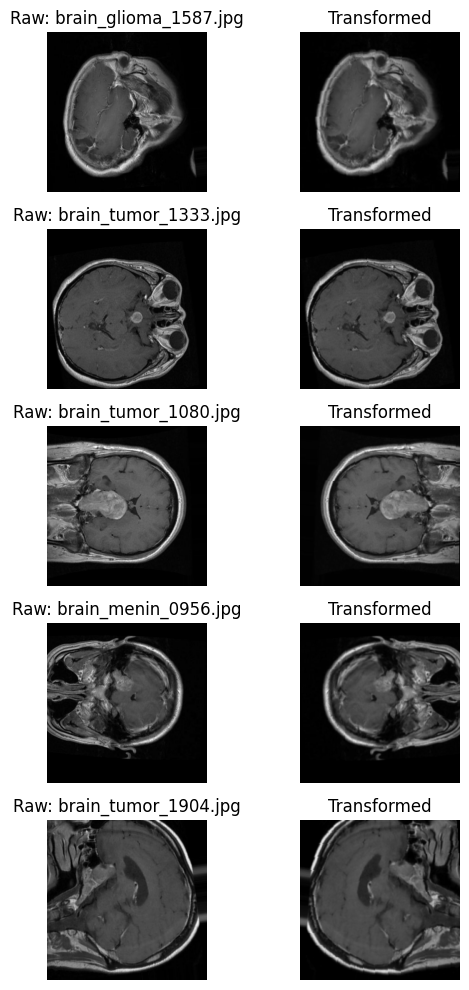

In [8]:
   
with open("artifacts/preprocessing/normalization_mean_std.json") as f:
    saved_mean_std = json.load(f)
mean, std = saved_mean_std["mean"], saved_mean_std["std"]

plot_raw_vs_transformed_imgs(dataset=train_dataset, n_samples=5, mean=mean, std=std)

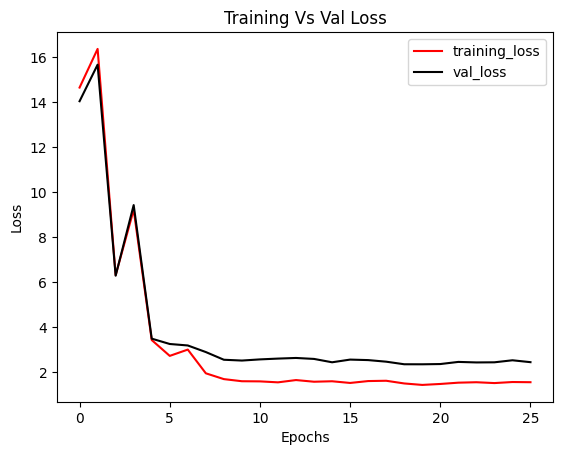

In [9]:
history = load_objects("artifacts/history/history_brain_cnn_baseline.pth")
    
plot_train_vs_val(history=history, metric="loss", title="Training Vs Val Loss", y_label="Loss", save_name="train_vs_val_loss")


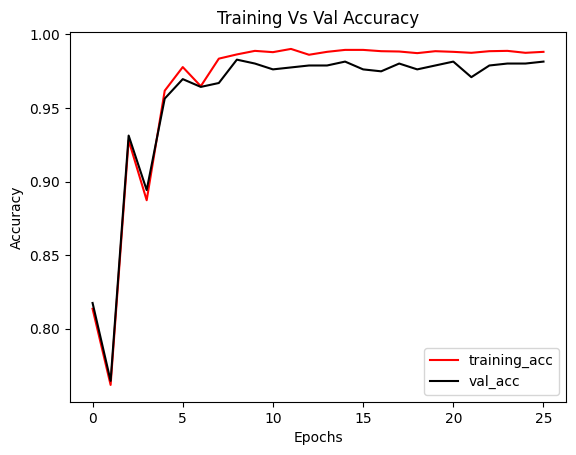

In [10]:
plot_train_vs_val(history=history, metric="acc", title="Training Vs Val Accuracy", y_label="Accuracy", save_name="train_vs_val_accuracy")

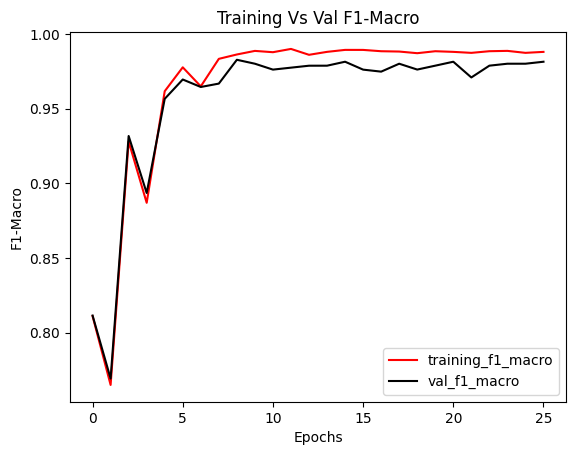

In [11]:
plot_train_vs_val(history=history, metric="f1_macro", title="Training Vs Val F1-Macro", y_label="F1-Macro", save_name="train_vs_val_f1_macro")

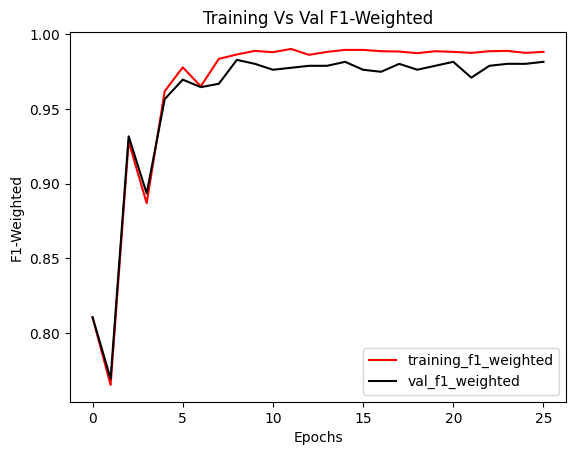

In [12]:
plot_train_vs_val(history=history, metric="f1_weighted", title="Training Vs Val F1-Weighted", y_label="F1-Weighted", save_name="train_vs_val_g1_weighted")

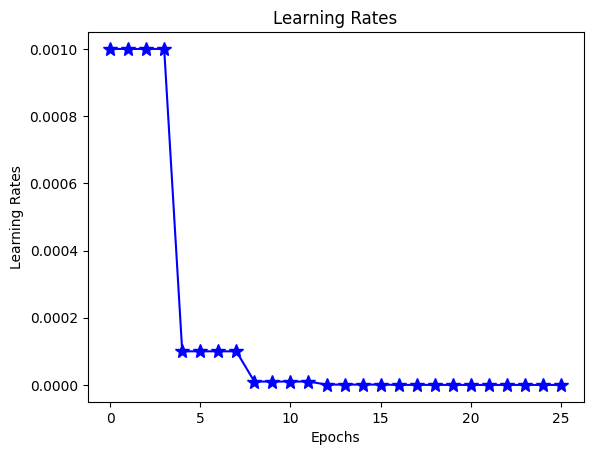

In [15]:
plot_learning_rates(history, color="b", marker="*", markersize=10, title="Learning Rates", save_name="learning_rates")